## Setup

In [1]:
!pip install transformers datasets scikit-learn matplotlib seaborn scipy

import os
import ast
import json
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, mean_squared_error, ndcg_score
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Load data

In [2]:
import ast

DATA_PATH = '/kaggle/input/notebooks/srivarshitha16/data-preparation-inlp-project' 
GRAPH_PATH = '/kaggle/input/notebooks/srivarshitha16/gnn-pre-training' 

# 2. Load Data
train_df = pd.read_csv(os.path.join(DATA_PATH, 'train_clean.csv'))
test_df = pd.read_csv(os.path.join(DATA_PATH, 'test_clean.csv'))

# Safely parse the extracted skills string back to a Python list
def parse_skills(skill_str):
    try: return ast.literal_eval(skill_str)
    except: return []

train_df['extracted_skills_res'] = train_df['extracted_skills_res'].apply(parse_skills)
train_df['extracted_skills_jd'] = train_df['extracted_skills_jd'].apply(parse_skills)
test_df['extracted_skills_res'] = test_df['extracted_skills_res'].apply(parse_skills)
test_df['extracted_skills_jd'] = test_df['extracted_skills_jd'].apply(parse_skills)

# 3. Load GNN Embeddings and Vocab mapping
with open(os.path.join(DATA_PATH, 'skill_vocab.json'), 'r') as f:
    skill_vocab = json.load(f)
skill_to_id = {skill: i for i, skill in enumerate(skill_vocab)}

pretrained_skill_embs = torch.tensor(np.load(os.path.join(GRAPH_PATH, 'skill_embeddings.npy')), dtype=torch.float32)

print(f"Loaded Train: {len(train_df)} | Test: {len(test_df)}")
print(f"Loaded GNN Embeddings Shape: {pretrained_skill_embs.shape} (These power the Graph variants!)")

def get_skill_ids(skills):
    return[skill_to_id[s] for s in skills if s in skill_to_id]

train_df['res_skill_ids'] = train_df['extracted_skills_res'].apply(get_skill_ids)
train_df['jd_skill_ids'] = train_df['extracted_skills_jd'].apply(get_skill_ids)
test_df['res_skill_ids'] = test_df['extracted_skills_res'].apply(get_skill_ids)
test_df['jd_skill_ids'] = test_df['extracted_skills_jd'].apply(get_skill_ids)

# Dictionary to store our final results across all experiments
experiment_results = {}

Loaded Train: 6241 | Test: 1759
Loaded GNN Embeddings Shape: torch.Size([2500, 128]) (These power the Graph variants!)


## Traditional Baseline - TF-IDF

### Experiment 1: The Traditional ATS Baseline (TF-IDF)
Before using Deep Learning, we must establish a baseline. Traditional ATS systems rely on exact keyword matching. We simulate this using TF-IDF and Cosine Similarity.
**Hypothesis:** This will perform poorly because it misses semantic meaning (e.g., penalizing a candidate who writes "Software Engineering" instead of "Programming").

In [3]:
print("Running TF-IDF Baseline...")

# Train TF-IDF on all text
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf.fit(train_df['resume_text'].tolist() + train_df['smart_jd_text'].tolist())

# Test it
tfidf_preds =[]
for idx, row in test_df.iterrows():
    res_vec = tfidf.transform([row['resume_text']])
    jd_vec = tfidf.transform([row['smart_jd_text']])
    sim = cosine_similarity(res_vec, jd_vec)[0][0]
    tfidf_preds.append(sim)

experiment_results['TF-IDF'] = np.array(tfidf_preds)
print("TF-IDF evaluation complete.")

Running TF-IDF Baseline...
TF-IDF evaluation complete.


## Neural models preparation

### Moving to Deep Learning
To capture semantic meaning, we move to Transformer models. We define a single PyTorch Dataset and a reusable Training loop to conduct an Architectural Evolution study:
1. **Pure Semantic:** Text only (like Resume2Vec). Black box, no recourse.
2. **Late Fusion:** Concatenates Text embedding with GNN embedding. Better, but entangles features.
3. **Cross-Attention:** Text actively queries the GNN graph. High accuracy.
4. **Mixture of Experts (MoE):** Distinct Text and Graph experts. Designed specifically for Explainability and Recourse.

## Dataloaders and Training loop

In [4]:
MODEL_NAME = 'cross-encoder/ms-marco-MiniLM-L-6-v2'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ResumeJDDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        encoding = tokenizer(str(row['resume_text']), str(row['smart_jd_text']),
                             max_length=512, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'res_skill_ids': row['res_skill_ids'],
            'jd_skill_ids': row['jd_skill_ids'],
            'target': torch.tensor(row['score'], dtype=torch.float)
        }

def custom_collate(batch):
    return {
        'input_ids': torch.stack([item['input_ids'] for item in batch]),
        'attention_mask': torch.stack([item['attention_mask'] for item in batch]),
        'res_skill_ids': [item['res_skill_ids'] for item in batch],
        'jd_skill_ids': [item['jd_skill_ids'] for item in batch],
        'target': torch.stack([item['target'] for item in batch])
    }

train_loader = DataLoader(ResumeJDDataset(train_df), batch_size=16, shuffle=True, collate_fn=custom_collate)
test_loader = DataLoader(ResumeJDDataset(test_df), batch_size=16, shuffle=False, collate_fn=custom_collate)

# --- REUSABLE TRAINING FUNCTION ---
def train_and_predict(model, epochs=3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()
    
    for epoch in range(epochs):
        model.train()
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            optimizer.zero_grad()
            preds = model(batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['res_skill_ids'], batch['jd_skill_ids'])
            if isinstance(preds, tuple): preds = preds[0] # Handle MoE tuple
            loss = criterion(preds, batch['target'].to(device))
            loss.backward()
            optimizer.step()
            
    model.eval()
    all_preds, t_scores, g_scores = [], [],[]
    with torch.no_grad():
        for batch in test_loader:
            preds = model(batch['input_ids'].to(device), batch['attention_mask'].to(device), batch['res_skill_ids'], batch['jd_skill_ids'])
            if isinstance(preds, tuple): # If MoE, extract diagnostics
                all_preds.extend(preds[0].cpu().numpy())
                t_scores.extend(preds[2].cpu().numpy())
                g_scores.extend(preds[3].cpu().numpy())
            else:
                all_preds.extend(preds.cpu().numpy())
    
    # Free memory
    del optimizer; gc.collect(); torch.cuda.empty_cache()
    return np.array(all_preds), t_scores, g_scores

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

## Define the 4 architectures

In [5]:
from torch.nn.utils.rnn import pad_sequence

# 1. Pure Semantic (Transformer Only)
class PureSemantic(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(MODEL_NAME)
        self.mlp = nn.Sequential(nn.Linear(self.transformer.config.hidden_size, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
    def forward(self, input_ids, attention_mask, *args):
        cls_emb = self.transformer(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        return self.mlp(cls_emb).squeeze(-1)

# 2. Late Fusion (Text + Graph Concatenation)
class LateFusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(MODEL_NAME)
        self.skill_embs = nn.Embedding.from_pretrained(pretrained_skill_embs, freeze=False)
        self.mlp = nn.Sequential(nn.Linear(self.transformer.config.hidden_size + 256, 128), nn.ReLU(), nn.Linear(128, 1), nn.Sigmoid())
    def forward(self, input_ids, attention_mask, res_ids, jd_ids):
        cls_emb = self.transformer(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        r_g, j_g = [],[]
        for i in range(cls_emb.size(0)):
            r_g.append(self.skill_embs(torch.tensor(res_ids[i], device=device)).mean(dim=0) if res_ids[i] else torch.zeros(128, device=device))
            j_g.append(self.skill_embs(torch.tensor(jd_ids[i], device=device)).mean(dim=0) if jd_ids[i] else torch.zeros(128, device=device))
        return self.mlp(torch.cat([cls_emb, torch.stack(r_g), torch.stack(j_g)], dim=1)).squeeze(-1)

# 3. Cross-Attention
class CrossAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(MODEL_NAME)
        self.skill_embs = nn.Embedding.from_pretrained(pretrained_skill_embs, freeze=False)
        self.proj = nn.Linear(128, self.transformer.config.hidden_size)
        self.attn = nn.MultiheadAttention(embed_dim=self.transformer.config.hidden_size, num_heads=4, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(self.transformer.config.hidden_size * 2, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
    def forward(self, input_ids, attention_mask, res_ids, jd_ids):
        seq = self.transformer(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        cls_emb = seq[:, 0, :]
        graph_seqs =[self.skill_embs(torch.tensor(res_ids[i]+jd_ids[i], device=device)) if (res_ids[i]+jd_ids[i]) else torch.zeros((1, 128), device=device) for i in range(seq.size(0))]
        proj_g = self.proj(pad_sequence(graph_seqs, batch_first=True))
        attn_out, _ = self.attn(query=seq, key=proj_g, value=proj_g)
        return self.mlp(torch.cat([cls_emb, attn_out[:, 0, :]], dim=1)).squeeze(-1)

# 4. Mixture of Experts (Our Proposed Solution)
class MoE_Fusion(nn.Module):
    def __init__(self):
        super().__init__()
        self.transformer = AutoModel.from_pretrained(MODEL_NAME)
        self.skill_embs = nn.Embedding.from_pretrained(pretrained_skill_embs, freeze=False)
        dim = self.transformer.config.hidden_size
        self.text_expert = nn.Sequential(nn.Linear(dim, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
        self.graph_expert = nn.Sequential(nn.Linear(256, 64), nn.ReLU(), nn.Linear(64, 1), nn.Sigmoid())
        self.gate = nn.Sequential(nn.Linear(dim + 256, 64), nn.ReLU(), nn.Linear(64, 2), nn.Softmax(dim=1))
    def forward(self, input_ids, attention_mask, res_ids, jd_ids):
        cls_emb = self.transformer(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        r_g, j_g = [],[]
        for i in range(cls_emb.size(0)):
            r_g.append(self.skill_embs(torch.tensor(res_ids[i], device=device)).mean(dim=0) if res_ids[i] else torch.zeros(128, device=device))
            j_g.append(self.skill_embs(torch.tensor(jd_ids[i], device=device)).mean(dim=0) if jd_ids[i] else torch.zeros(128, device=device))
        g_tensor = torch.cat([torch.stack(r_g), torch.stack(j_g)], dim=1)
        t_score = self.text_expert(cls_emb)
        g_score = self.graph_expert(g_tensor)
        gates = self.gate(torch.cat([cls_emb, g_tensor], dim=1))
        f_score = (gates[:, 0].unsqueeze(1) * t_score) + (gates[:, 1].unsqueeze(1) * g_score)
        return f_score.squeeze(-1), gates, t_score.squeeze(-1), g_score.squeeze(-1)

## Train all models

In [6]:
print("Training Pure Semantic...")
experiment_results['Pure Semantic'], _, _ = train_and_predict(PureSemantic().to(device))

print("\nTraining Late Fusion...")
experiment_results['Late Fusion'], _, _ = train_and_predict(LateFusion().to(device))

print("\nTraining Cross-Attention...")
experiment_results['Cross-Attention'], _, _ = train_and_predict(CrossAttention().to(device))

print("\nTraining Mixture of Experts...")
moe_model = MoE_Fusion().to(device)
experiment_results['MoE'], moe_t_scores, moe_g_scores = train_and_predict(moe_model)


Training Pure Semantic...


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3:   0%|          | 0/391 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/391 [00:00<?, ?it/s]

## Evaluation

### Evaluation Metrics Justification
For ATS systems, pure error (MAE) is less important than ranking. HR doesn't care if a score is 0.7 or 0.8, they care if the *best* candidate is at the top of the pile. 
Therefore, we use:
* **nDCG@10:** Did the top 10 candidates retrieved match the human's top 10?
* **RBO (Rank-Biased Overlap):** Measures top-weighted list similarity.
* **Spearman $\rho$:** Evaluates overall monotonic ranking correlation.

In [7]:
def calculate_rbo(list1, list2, p=0.9):
    """Calculates Rank-Biased Overlap."""
    if not list1 or not list2: return 0.0
    sl, ll = (list1, list2) if len(list1) < len(list2) else (list2, list1)
    overlap, weight = 0.0, 0.0
    for i in range(1, len(sl) + 1):
        agreement = len(set(sl[:i]).intersection(set(ll[:i])))
        w = (1 - p) * (p ** (i - 1))
        overlap += w * (agreement / i)
        weight += w
    return overlap / weight if weight > 0 else 0.0

metrics_data =[]

for model_name, preds in experiment_results.items():
    df_eval = test_df.copy()
    df_eval['pred'] = preds
    
    mae = mean_absolute_error(df_eval['score'], preds)
    spearman, _ = spearmanr(df_eval['score'], preds)
    
    ndcg_list, rbo_list = [],[]
    for job, group in df_eval.groupby('job_description_text'):
        if len(group) > 1:
            y_true = np.asarray([group['score'].values])
            y_pred = np.asarray([group['pred'].values])
            if len(group) >= 10: 
                ndcg_list.append(ndcg_score(y_true, y_pred, k=10))
                
            true_ranks = group.sort_values('score', ascending=False).index.tolist()
            pred_ranks = group.sort_values('pred', ascending=False).index.tolist()
            rbo_list.append(calculate_rbo(true_ranks, pred_ranks))
            
    metrics_data.append({
        'Model': model_name,
        'MAE': mae,
        'Spearman': spearman,
        'nDCG@10': np.mean(ndcg_list),
        'RBO': np.mean(rbo_list)
    })

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df.round(4))

,Model,MAE,Spearman,nDCG@10,RBO
0,TF-IDF,0.3802,0.0908,0.6328,0.3927
1,Pure Semantic,0.3767,0.0899,0.6453,0.3946
2,Late Fusion,0.3793,0.0528,0.5607,0.4034
3,Cross-Attention,0.3619,0.1961,0.6004,0.4070
4,MoE,0.3737,0.1070,0.6032,0.4162


## Plots

/tmp/ipykernel_24/1009881902.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Model', y='nDCG@10', ax=axes[0], palette='viridis')


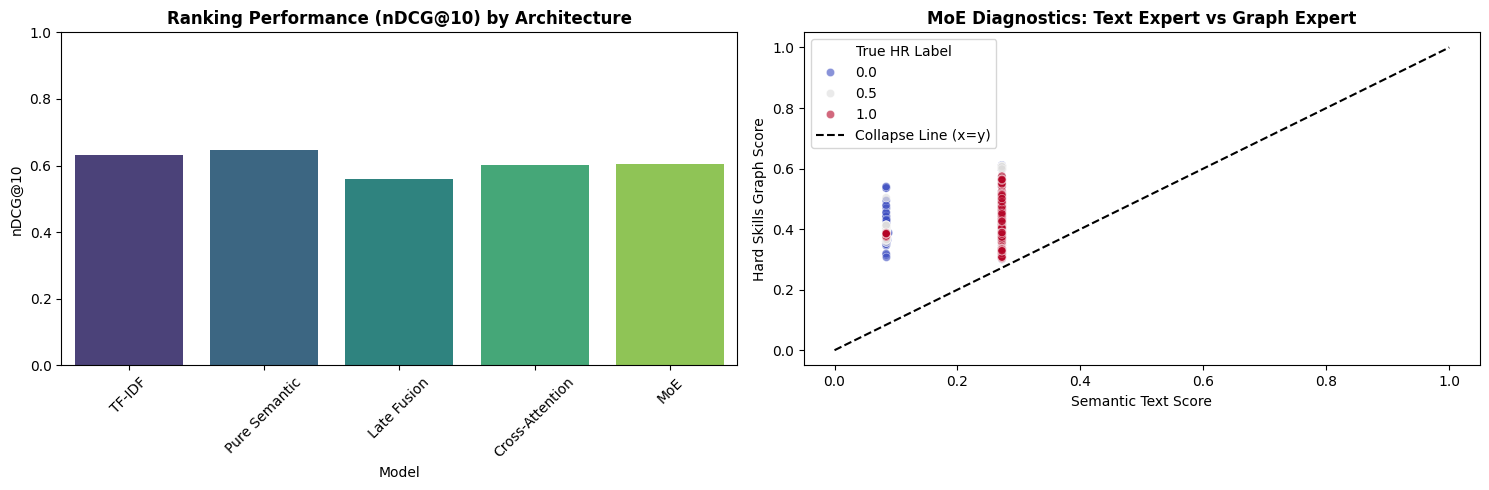

CONCLUSION: As shown in the bar chart, Fusion models outperform TF-IDF and Pure Semantic models.
While Cross-Attention might have peak nDCG, MoE performs competitively while providing separated experts.
The scatter plot proves our MoE did NOT collapse (the points do not hug the x=y line), enabling Phase 4 Recourse!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Metric Progression (nDCG shows ranking power)
sns.barplot(data=metrics_df, x='Model', y='nDCG@10', ax=axes[0], palette='viridis')
axes[0].set_title('Ranking Performance (nDCG@10) by Architecture', fontweight='bold')
axes[0].set_ylim(0, 1.0)
for item in axes[0].get_xticklabels(): item.set_rotation(45)

# Plot 2: Proving the MoE works (Fixing Expert Collapse)
sns.scatterplot(x=moe_t_scores, y=moe_g_scores, hue=test_df['score'], palette='coolwarm', alpha=0.6, ax=axes[1])
axes[1].plot([0, 1], [0, 1], color='black', linestyle='--', label='Collapse Line (x=y)')
axes[1].set_title("MoE Diagnostics: Text Expert vs Graph Expert", fontweight='bold')
axes[1].set_xlabel("Semantic Text Score")
axes[1].set_ylabel("Hard Skills Graph Score")
axes[1].legend(title='True HR Label')

plt.tight_layout()
plt.show()

print("CONCLUSION: As shown in the bar chart, Fusion models outperform TF-IDF and Pure Semantic models.")
print("While Cross-Attention might have peak nDCG, MoE performs competitively while providing separated experts.")
print("The scatter plot proves our MoE did NOT collapse (the points do not hug the x=y line), enabling Phase 4 Recourse!")

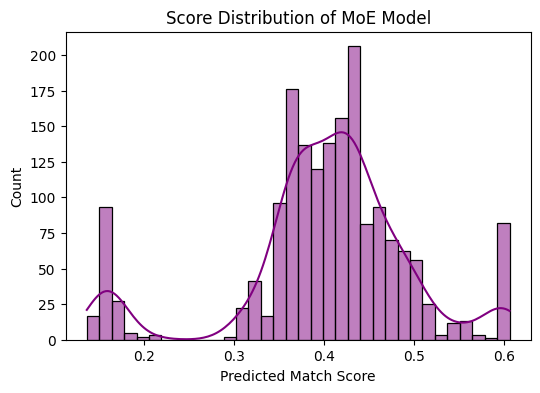

In [9]:
plt.figure(figsize=(6,4))
sns.histplot(experiment_results['MoE'], kde=True, color='purple')
plt.title("Score Distribution of MoE Model")
plt.xlabel("Predicted Match Score")
plt.show()

## Save

In [10]:
print("Training Pure Semantic...")
pure_semantic_model = PureSemantic().to(device)
experiment_results['Pure Semantic'], _, _ = train_and_predict(pure_semantic_model)
torch.save(pure_semantic_model.state_dict(), '/kaggle/working/best_pure_semantic.pth')
print("-> Saved Pure Semantic model.")

print("\nTraining Late Fusion...")
late_fusion_model = LateFusion().to(device)
experiment_results['Late Fusion'], _, _ = train_and_predict(late_fusion_model)
torch.save(late_fusion_model.state_dict(), '/kaggle/working/best_late_fusion.pth')
print("-> Saved Late Fusion model.")

print("\nTraining Cross-Attention...")
ca_model = CrossAttention().to(device)
experiment_results['Cross-Attention'], _, _ = train_and_predict(ca_model)
torch.save(ca_model.state_dict(), '/kaggle/working/best_cross_attention.pth')
print("-> Saved Cross-Attention model.")

print("\nTraining Mixture of Experts...")
moe_model = MoE_Fusion().to(device)
experiment_results['MoE'], moe_t_scores, moe_g_scores = train_and_predict(moe_model)
torch.save(moe_model.state_dict(), '/kaggle/working/best_moe_model.pth')
print("-> Saved MoE model.")

print("\nAll 4 Deep Learning architectures trained and saved successfully to /kaggle/working/!")

Training Pure Semantic...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/391 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1/3:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 2/3:   0%|          | 0/391 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/391 [00:00<?, ?it/s]

-> Saved MoE model.

All 4 Deep Learning architectures trained and saved successfully to /kaggle/working/!
